In [ ]:
# To check that dataset ('all_stocks_5yr.csv') has been uploaded. 
# Dataset: S&P 500 Stock Prices (all_stocks_5yr.csv)
# Source: https://www.kaggle.com/datasets/camnugent/sandp500

import os
os.listdir('/content')

['.config', 'all_stocks_5yr.csv', 'sample_data']

In [49]:
# ============================================================
# ****** STEP 1: DATASET OVERVIEW ******
# ============================================================
# Load dataset, inspect structure, check missing values, and understand panel format.

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import warnings

warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 100


df = pd.read_csv('/content/all_stocks_5yr.csv', parse_dates=['date'])

df.columns = df.columns.str.strip().str.lower()

print('Shape:', df.shape)
print('Date range:', df['date'].min(), '→', df['date'].max())
print('Unique stocks:', df['name'].nunique())

print('\nMissing values:\n', df.isnull().sum())

df.head()

Shape: (619040, 7)
Date range: 2013-02-08 00:00:00 → 2018-02-07 00:00:00
Unique stocks: 505

Missing values:
 date       0
open      11
high       8
low        8
close      0
volume     0
name       0
dtype: int64


,date,open,high,low,close,volume,name
0,2013-02-08,15.07,15.12,14.63,14.75,8407500,AAL
1,2013-02-11,14.89,15.01,14.26,14.46,8882000,AAL
2,2013-02-12,14.45,14.51,14.10,14.27,8126000,AAL
3,2013-02-13,14.30,14.94,14.25,14.66,10259500,AAL
4,2013-02-14,14.94,14.96,13.16,13.99,31879900,AAL


In [50]:
# ============================================================
# ****** STEP 2: KEY STATISTICS ******
# ============================================================
# Central tendencies, spreads, and distribution shape.

df['spread'] = df['high'] - df['low']
df['up_day'] = df['close'] > df['open']

# NOTE: describe() here is global across all stocks (acceptable for EDA)
print(df.describe().round(2))

pct_up = df['up_day'].mean() * 100
print(f"\nPercent of up days: {pct_up:.1f}%")

# Skewness and kurtosis (distribution shape indicators)
for col in ['open', 'high', 'low', 'close', 'volume']:
    print(f"{col:8s} | skew: {df[col].skew():6.2f} | kurt: {df[col].kurtosis():6.2f}")

# Extra improvement: per-stock signal (more meaningful than global only)
top_mean_close = (
    df.groupby('name')['close']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)
print("\nTop 10 stocks by average close price:")
print(top_mean_close)

                                date       open       high        low  \
count                         619040  619029.00  619032.00  619032.00   
mean   2015-08-18 00:48:23.494443264      83.02      83.78      82.26   
min              2013-02-08 00:00:00       1.62       1.69       1.50   
25%              2014-05-20 00:00:00      40.22      40.62      39.83   
50%              2015-08-21 00:00:00      62.59      63.15      62.02   
75%              2016-11-15 00:00:00      94.37      95.18      93.54   
max              2018-02-07 00:00:00    2044.00    2067.99    2035.11   
std                              NaN      97.38      98.21      96.51   

           close        volume     spread  
count  619040.00  6.190400e+05  619032.00  
mean       83.04  4.321823e+06       1.52  
min         1.59  0.000000e+00      -0.26  
25%        40.24  1.070320e+06       0.61  
50%        62.62  2.082094e+06       0.99  
75%        94.41  4.284509e+06       1.67  
max      2049.00  6.182376e+08    

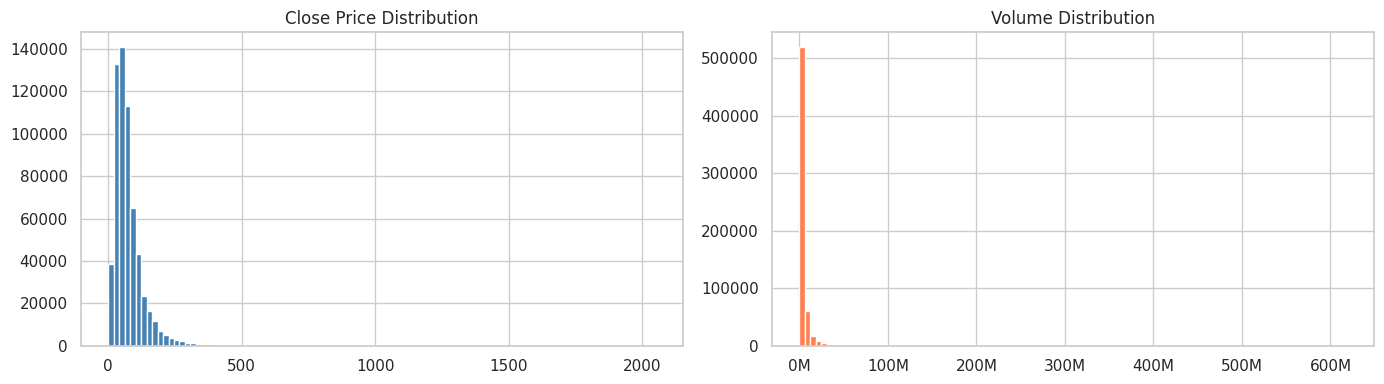

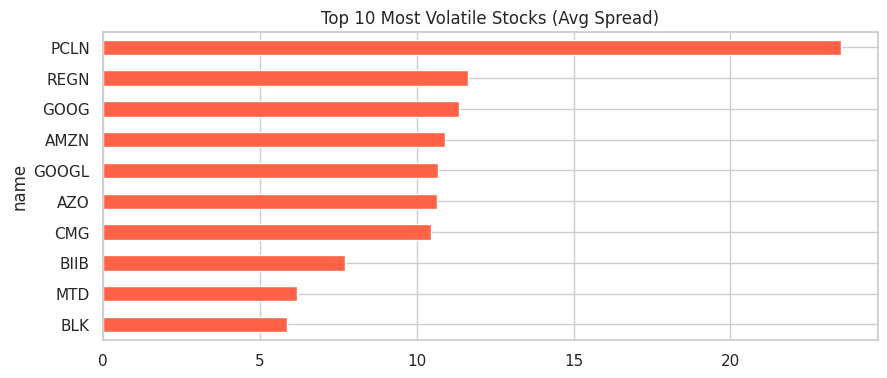

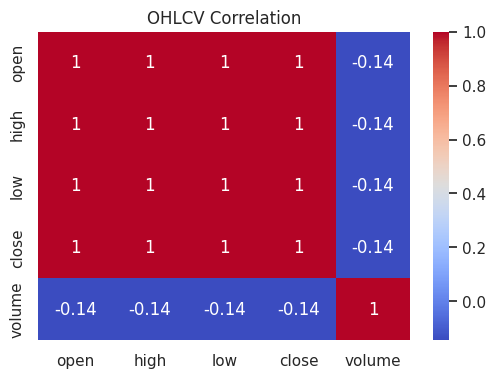

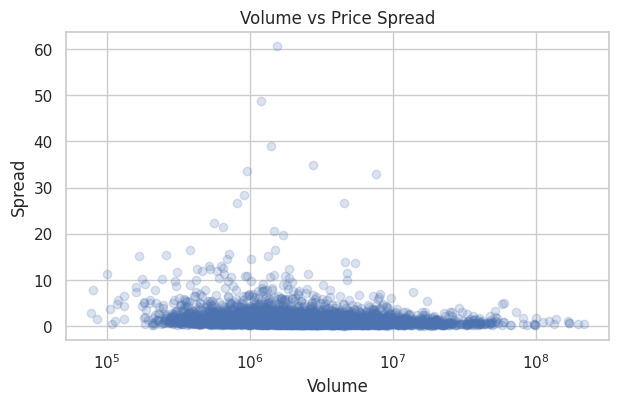

Pearson r = nan, p-value = nan


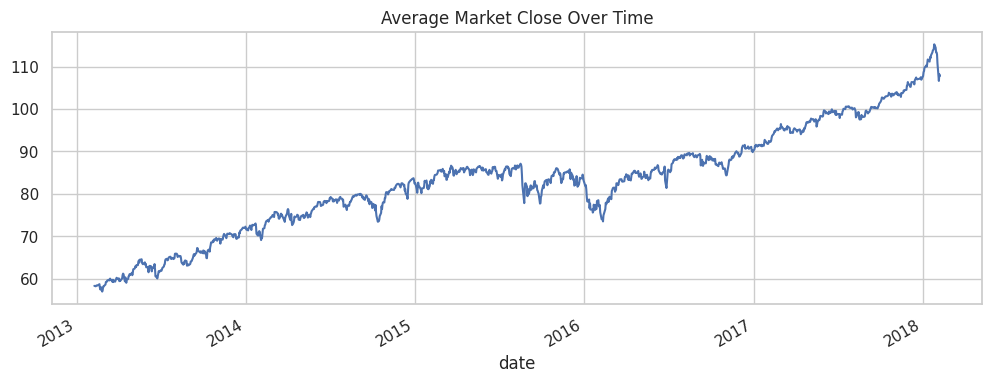

In [51]:
# ============================================================
# ****** STEP 3: CRITICAL VISUALS ******
# ============================================================
# Core EDA plots: distributions, volatility, correlation, relationships, trends.

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(df['close'], bins=100, color='steelblue')
axes[0].set_title('Close Price Distribution')

axes[1].hist(df['volume'], bins=100, color='coral')
axes[1].set_title('Volume Distribution')
axes[1].xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M')
)

plt.tight_layout()
plt.show()


# ============================================================
# Volatility (spread-based, simple proxy)
# ============================================================

df.groupby('name')['spread'].mean().sort_values(ascending=False).head(10).plot(
    kind='barh', color='tomato', figsize=(10, 4)
)
plt.title("Top 10 Most Volatile Stocks (Avg Spread)")
plt.gca().invert_yaxis()
plt.show()


# ============================================================
# Correlation structure (OHLCV)
# ============================================================

plt.figure(figsize=(6, 4))
sns.heatmap(df[['open','high','low','close','volume']].corr(),
            annot=True, cmap='coolwarm')
plt.title("OHLCV Correlation")
plt.show()


# ============================================================
# Volume vs. price movement relationship
# ============================================================

sample = df.sample(5000, random_state=42)

plt.figure(figsize=(7, 4))
plt.scatter(sample['volume'], sample['spread'], alpha=0.2)
plt.xscale('log')
plt.title("Volume vs Price Spread")
plt.xlabel("Volume")
plt.ylabel("Spread")
plt.show()

r, p = stats.pearsonr(df['volume'], df['spread'])
print(f"Pearson r = {r:.3f}, p-value = {p:.4f}")


# ============================================================
# Market-wide trend
# ============================================================

df.groupby('date')['close'].mean().plot(figsize=(12, 4))
plt.title("Average Market Close Over Time")
plt.show()


In [52]:
# ============================================================
# ****** STEP 4: HYPOTHESES ******
# ============================================================
# Assumptions based on observed patterns

print("HYPOTHESES:")
print("1. Higher volume days correspond to larger price movements.")
print("2. Volatility varies significantly across different stocks.")
print("3. Market-wide average close reflects long-term structural movement in dataset.")

HYPOTHESES:
1. Higher volume days correspond to larger price movements.
2. Volatility varies significantly across different stocks.
3. Market-wide average close reflects long-term structural movement in dataset.


In [53]:
# ============================================================
# ****** STEP 5: FURTHER INVESTIGATION ******
# ============================================================
# Outlier detection using statistical methods

# Z-score for volume
df['volume_z'] = stats.zscore(df['volume'])

volume_outliers = df[df['volume_z'].abs() > 3]
print("Volume outliers:", len(volume_outliers))

# IQR method for price outliers
Q1, Q3 = df['close'].quantile([0.25, 0.75])
IQR = Q3 - Q1

price_outliers = df[
    (df['close'] < Q1 - 1.5 * IQR) |
    (df['close'] > Q3 + 1.5 * IQR)
]

print("Price outliers:", len(price_outliers))

Volume outliers: 9570
Price outliers: 38941
